# Predição da Resistência à Compressão de Concretos Utilizando Redes Neurais MLP: Aprendizado de Máquina e Otimização

Autor: André de Araújo Caetano

Github do Projeto: [Github](https://github.com/andre-aracaetano/study-of-mlp-and-genetic-algorithm-with-a-cement-dataset)

## Bibliotecas

In [49]:
import kagglehub # Opcional para donwload do dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools, random, time
import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 67
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 1. Preparação do dataset

Download do dataset diretamente do Kaggle

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vinayakshanawad/cement-manufacturing-concrete-dataset")

print("Path to dataset files:", path)

100%|██████████| 11.1k/11.1k [00:00<00:00, 7.56MB/s]

Extracting files...
Path to dataset files: C:\Users\andre\.cache\kagglehub\datasets\vinayakshanawad\cement-manufacturing-concrete-dataset\versions\1


In [2]:
df = pd.read_csv("concrete.csv")
print(df.shape)
print(df.columns.tolist())
display(df)

(1030, 9)
['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg', 'fineagg', 'age', 'strength']


,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29
...,...,...,...,...,...,...,...,...,...
1025,135.0,0.0,166.0,180.0,10.0,961.0,805.0,28,13.29
1026,531.3,0.0,0.0,141.8,28.2,852.1,893.7,3,41.30
1027,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1028,342.0,38.0,0.0,228.0,0.0,932.0,670.0,270,55.06


Para o problema que estou trabalhando, eu quero utilizar os compostos que compoem o concreto para prever sua "strength", que neste caso significa capacidade de compressão.

O significado das colunas é:

- **Cimento:** É o aglomerante principal do concreto, responsável por unir os materiais. Medido em quilogramas por metro cúbico de mistura ($\mathrm{kg/m^3}$).

- **Escória de alto-forno:** Um subproduto da indústria siderúrgica que pode ser usado como adição ao concreto para melhorar suas propriedades. Medido em quilogramas por metro cúbico de mistura ($\mathrm{kg/m^3}$).

- **Cinzas volantes:** Resíduo da queima de carvão em usinas termelétricas, utilizado no concreto para melhorar sua durabilidade. Medido em quilogramas por metro cúbico de mistura ($\mathrm{kg/m^3}$).

- **Água:** Essencial para a hidratação do cimento e a mistura dos materiais. Medida em quilogramas por metro cúbico de mistura ($\mathrm{kg/m^3}$).

- **Superplastificante:** Aditivo que melhora a trabalhabilidade do concreto sem comprometer sua resistência. Medido em quilogramas por metro cúbico de mistura ($\mathrm{kg/m^3}$).

- **Agregado graúdo:** Pedras ou britas que compõem o concreto, fornecendo resistência mecânica. Medido em quilogramas por metro cúbico de mistura ($\mathrm{kg/m^3}$).

- **Agregado miúdo:** Areia ou pó de pedra que preenche os vazios entre os agregados graúdos, melhorando a trabalhabilidade. Medido em quilogramas por metro cúbico de mistura ($\mathrm{kg/m^3}$).

- **Idade:** Tempo, em dias, desde a mistura do concreto. Varia de 1 a 365 dias.

- **Resistência à compressão do concreto:** Medida em Megapascal ($\mathrm{MPa}$), indica a capacidade do concreto de suportar cargas de compressão.

É interessante notar que, com excessão do nosso Target e da Idade, todas as outras colunas são dadas em $\mathrm{kg/m^3}$, inclusive a água.

Nenhuma limpeza é necessária pois este dataset já está bem estabelecido, sem valores nan ou valores que divergem do esperado.

In [3]:
TARGET = "strength"

Podemos plotar um gráfico de correlação inicial para entender melhor como as features estão organizadas e o balanceamento dos dados do Target.

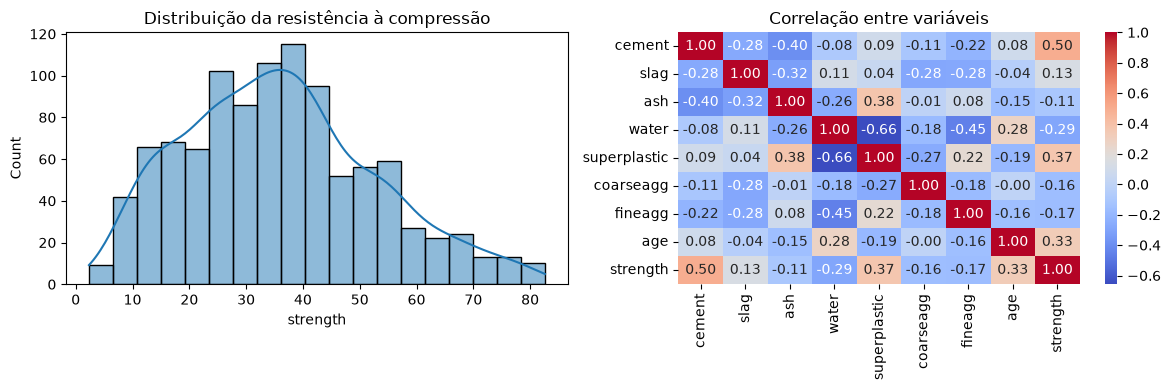

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[TARGET], kde=True, ax=axes[0])
axes[0].set_title("Distribuição da resistência à compressão")

sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Correlação entre variáveis")
plt.tight_layout()
plt.show()

O dataset faz sentido do ponto de vista das ciências dos materiais. A força tem grande influência do cimento, da adição do plastificante e do tempo de "cura" do material, que é a "age". Além disso, a água apresenta uma correlação contrária, o que também faz sentido, a relação água/cimento é bem definida pela diluição do material que irá solidificar pela quantidade de água, diminuindo a resistência a compressão.

### Split de treino e teste com normalização (85/15)

In [41]:
X = df.drop(columns=[TARGET]).values.astype(np.float32)
y = df[TARGET].values.astype(np.float32).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED
)

scaler_X = StandardScaler().fit(X_train)
X_train_scaled = scaler_X.transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Também vale normalizar o alvo, desnormalizamos na hora de avaliar.
scaler_y = StandardScaler().fit(y_train)
y_train_scaled = scaler_y.transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

print("Treino:", X_train_scaled.shape, " Teste:", X_test_scaled.shape)

Treino: (875, 8)  Teste: (155, 8)


## 2. Construção da MLP

In [42]:
class ConcreteDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class MLP(nn.Module):
    def __init__(self, in_features, hidden=(64, 32), dropout=0.15, activation=nn.ReLU):
        super().__init__()
        layers = []
        prev = in_features
        for h in hidden:
            layers += [nn.Linear(prev, h), activation(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

Também optei pela utilização de Early Stopping, que é uma técnica de treinamento utilizada para evitar o overfitting. Ela funciona monitorando o desempenho do modelo em um conjunto de validação separado durante o treinamento. Quando a métrica de validação deixa de melhorar por um número definido de iterações (parâmetro de paciência), o ciclo de treinamento é interrompido prematuramente.

In [43]:
MAX_EPOCHS = 300 
PATIENCE = 20 # Paciência do Early Stopping (quantas épocas sem melhora antes de parar)
LEARNING_RATE = 1e-3




def train_model(model, train_loader, val_loader, max_epochs=MAX_EPOCHS, patience=PATIENCE, lr=LEARNING_RATE, verbose=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_losses.append(criterion(model(xb), yb).item())
        val_loss = np.mean(val_losses)

        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and epoch % 20 == 0:
            print(f"Época {epoch:3d} | val_loss (MSE, escala normalizada): {val_loss:.4f}")

        if epochs_no_improve >= patience:
            if verbose:
                print(f"Early stopping na época {epoch}")
            break

    model.load_state_dict(best_state)
    return model, best_val_loss

### 2.1 Validação Cruzada

Cada fold treina um modelo do zero e mede o RMSE na parte de validação (na escala original, já desnormalizada). Isso dá uma estimativa mais robusta do desempenho do que um único split.

In [44]:
def run_kfold(X, y, n_splits=5, hidden=(64, 32), dropout=0.15, batch_size=32):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    fold_rmses = []

    for fold, (tr_idx, val_idx) in enumerate(kfold.split(X)):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        train_loader = DataLoader(ConcreteDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(ConcreteDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

        model = MLP(in_features=X.shape[1], hidden=hidden, dropout=dropout).to(device)
        model, _ = train_model(model, train_loader, val_loader)

        model.eval()
        with torch.no_grad():
            preds_scaled = model(torch.tensor(X_val, dtype=torch.float32).to(device)).cpu().numpy()

        # Desnormaliza para calcular RMSE em MPa (unidade real)
        preds = scaler_y.inverse_transform(preds_scaled)
        y_val_real = scaler_y.inverse_transform(y_val)

        rmse = np.sqrt(mean_squared_error(y_val_real, preds))
        fold_rmses.append(rmse)
        print(f"Fold {fold+1}/{n_splits} — RMSE: {rmse:.3f} MPa")

    print(f"\nRMSE médio (K-Fold): {np.mean(fold_rmses):.3f} ± {np.std(fold_rmses):.3f} MPa")
    return fold_rmses

fold_rmses = run_kfold(X_train_scaled, y_train_scaled, n_splits=5)

Fold 1/5 — RMSE: 4.648 MPa
Fold 2/5 — RMSE: 4.267 MPa
Fold 3/5 — RMSE: 5.430 MPa
Fold 4/5 — RMSE: 5.459 MPa
Fold 5/5 — RMSE: 5.394 MPa

RMSE médio (K-Fold): 5.040 ± 0.491 MPa


### 2.2 Modelo Final

In [45]:
# Fatia interna do treino só para o early stopping do modelo final
X_fit, X_val_final, y_fit, y_val_final = train_test_split(
    X_train_scaled, y_train_scaled, test_size=0.15, random_state=SEED
)

train_loader = DataLoader(ConcreteDataset(X_fit, y_fit), batch_size=32, shuffle=True)
val_loader = DataLoader(ConcreteDataset(X_val_final, y_val_final), batch_size=32, shuffle=False)

final_model = MLP(in_features=X_train_scaled.shape[1], hidden=(64, 32), dropout=0.15).to(device)
final_model, _ = train_model(final_model, train_loader, val_loader, verbose=True)

final_model.eval()
with torch.no_grad():
    test_preds_scaled = final_model(torch.tensor(X_test_scaled, dtype=torch.float32).to(device)).cpu().numpy()

test_preds = scaler_y.inverse_transform(test_preds_scaled)
y_test_real = scaler_y.inverse_transform(y_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test_real, test_preds))
mae = mean_absolute_error(y_test_real, test_preds)
r2 = r2_score(y_test_real, test_preds)

print(f"RMSE: {rmse:.3f} MPa")
print(f"MAE:  {mae:.3f} MPa")
print(f"R²:   {r2:.3f}")

Época   0 | val_loss (MSE, escala normalizada): 0.6581
Época  20 | val_loss (MSE, escala normalizada): 0.1606
Época  40 | val_loss (MSE, escala normalizada): 0.1083
Época  60 | val_loss (MSE, escala normalizada): 0.0985
Época  80 | val_loss (MSE, escala normalizada): 0.0997
Época 100 | val_loss (MSE, escala normalizada): 0.0931
Época 120 | val_loss (MSE, escala normalizada): 0.0960
Early stopping na época 136
RMSE: 4.658 MPa
MAE:  3.246 MPa
R²:   0.923


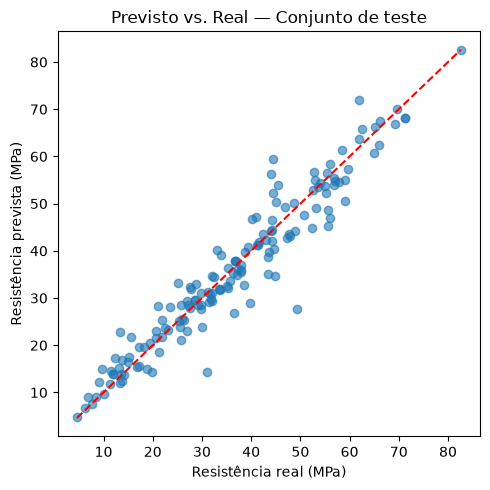

In [46]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test_real, test_preds, alpha=0.6)
lims = [min(y_test_real.min(), test_preds.min()), max(y_test_real.max(), test_preds.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Resistência real (MPa)")
plt.ylabel("Resistência prevista (MPa)")
plt.title("Previsto vs. Real — Conjunto de teste")
plt.tight_layout()
plt.show()

Okay, com essa baseline estabelecida posso começar a varias os hiperparâmetros buscando achar aquele em que meu RMSE é o mínimo possível. Vale ressaltar que, como o objetivo do projeto também visa aplicar Algoritmo genético e SHAP não vou me estender tanto na melhora do modelo.

### 2.3 Melhoria da MLP v1

In [27]:
def evaluate_config(hidden, dropout, lr, max_epochs, activation, n_splits=5):
    """K-Fold rápido (3 folds) só pra ranquear configurações na busca."""
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    rmses = []
    for tr_idx, val_idx in kfold.split(X_train_scaled):
        X_tr, X_val = X_train_scaled[tr_idx], X_train_scaled[val_idx]
        y_tr, y_val = y_train_scaled[tr_idx], y_train_scaled[val_idx]

        train_loader = DataLoader(ConcreteDataset(X_tr, y_tr), batch_size=32, shuffle=True)
        val_loader = DataLoader(ConcreteDataset(X_val, y_val), batch_size=32, shuffle=False)

        model = MLP(in_features=X_train_scaled.shape[1], hidden=hidden,
                    dropout=dropout, activation=activation).to(device)
        model, _ = train_model(model, train_loader, val_loader,
                                max_epochs=max_epochs, patience=40, lr=lr)

        model.eval()
        with torch.no_grad():
            preds_scaled = model(torch.tensor(X_val, dtype=torch.float32).to(device)).cpu().numpy()
        preds = scaler_y.inverse_transform(preds_scaled)
        y_val_real = scaler_y.inverse_transform(y_val)
        rmses.append(np.sqrt(mean_squared_error(y_val_real, preds)))

    return np.mean(rmses)

In [28]:
random.seed(SEED)

param_space = {
    "activation_name": ["ReLU"],
    "hidden": [(64,), (64,32), (128, 128), (256,), (256, 256, 256, 256)],
    "dropout": [0.15, 0.3, 0.5],
    "lr": [0.001, 0.01, 0.05],
    "max_epochs": [100, 150, 200],
}
activation_map = {"ReLU": nn.ReLU}

all_combos = list(itertools.product(*param_space.values()))
N_TRIALS = 30  # amostra aleatória em vez das 216 combinações completas

sampled = random.sample(all_combos, N_TRIALS)

results = []
for i, (act_name, hidden, dropout, lr, max_epochs) in enumerate(sampled):
    t0 = time.time()
    rmse = evaluate_config(hidden, dropout, lr, max_epochs, activation_map[act_name])
    print(f"[{i+1:2d}/{N_TRIALS}] act={act_name:5s} hidden={str(hidden):22s} "
          f"dropout={dropout:<4} lr={lr:<6} epochs={max_epochs:<3} "
          f"-> RMSE={rmse:.3f} MPa ({time.time()-t0:.1f}s)")
    results.append({"activation": act_name, "hidden": hidden, "dropout": dropout,
                     "lr": lr, "max_epochs": max_epochs, "rmse": rmse})

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
results_df

[ 1/30] act=ReLU  hidden=(64,)                  dropout=0.5  lr=0.001  epochs=150 -> RMSE=6.397 MPa (22.7s)
[ 2/30] act=ReLU  hidden=(64, 32)               dropout=0.15 lr=0.001  epochs=200 -> RMSE=4.945 MPa (35.3s)
[ 3/30] act=ReLU  hidden=(256,)                 dropout=0.5  lr=0.01   epochs=200 -> RMSE=5.477 MPa (21.9s)
[ 4/30] act=ReLU  hidden=(256, 256, 256, 256)   dropout=0.3  lr=0.001  epochs=200 -> RMSE=4.809 MPa (72.4s)
[ 5/30] act=ReLU  hidden=(256,)                 dropout=0.5  lr=0.05   epochs=150 -> RMSE=7.182 MPa (8.9s)
[ 6/30] act=ReLU  hidden=(128, 128)             dropout=0.3  lr=0.01   epochs=200 -> RMSE=5.184 MPa (31.4s)
[ 7/30] act=ReLU  hidden=(256, 256, 256, 256)   dropout=0.15 lr=0.001  epochs=150 -> RMSE=4.782 MPa (82.2s)
[ 8/30] act=ReLU  hidden=(256, 256, 256, 256)   dropout=0.3  lr=0.05   epochs=150 -> RMSE=13.790 MPa (45.6s)
[ 9/30] act=ReLU  hidden=(128, 128)             dropout=0.5  lr=0.05   epochs=150 -> RMSE=11.113 MPa (12.5s)
[10/30] act=ReLU  hidden=(6

,activation,hidden,dropout,lr,max_epochs,rmse
0,ReLU,"(128, 128)",0.15,0.001,200,4.507736
1,ReLU,"(256, 256, 256, 256)",0.15,0.001,150,4.782081
2,ReLU,"(256, 256, 256, 256)",0.30,0.001,200,4.808772
3,ReLU,"(256,)",0.15,0.010,150,4.906830
4,ReLU,"(64, 32)",0.15,0.001,200,4.945494
5,ReLU,"(256,)",0.30,0.010,200,4.988290
6,ReLU,"(64, 32)",0.15,0.010,150,4.996913
7,ReLU,"(256, 256, 256, 256)",0.30,0.001,100,5.092784
8,ReLU,"(64,)",0.15,0.010,150,5.101276
9,ReLU,"(64,)",0.15,0.010,200,5.110923


In [29]:
best = results_df.iloc[0]
print("Melhor configuração encontrada na busca:")
print(best)

best_hidden = best["hidden"]
best_dropout = best["dropout"]
best_lr = best["lr"]
best_epochs = best["max_epochs"]
best_activation = activation_map[best["activation"]]

Melhor configuração encontrada na busca:
activation          ReLU
hidden        (128, 128)
dropout             0.15
lr                 0.001
max_epochs           200
rmse            4.507736
Name: 0, dtype: object


In [30]:
# --- Confirmação final: 5-fold completo + avaliação no teste, com a melhor config ---
final_rmse_kfold = evaluate_config(best_hidden, best_dropout, best_lr, best_epochs,
                                    best_activation, n_splits=5)
print(f"RMSE médio (5-fold) com a melhor config: {final_rmse_kfold:.3f} MPa")

X_fit, X_val_final, y_fit, y_val_final = train_test_split(
    X_train_scaled, y_train_scaled, test_size=0.15, random_state=SEED
)
train_loader = DataLoader(ConcreteDataset(X_fit, y_fit), batch_size=32, shuffle=True)
val_loader = DataLoader(ConcreteDataset(X_val_final, y_val_final), batch_size=32, shuffle=False)

final_model = MLP(in_features=X_train_scaled.shape[1], hidden=best_hidden,
                   dropout=best_dropout, activation=best_activation).to(device)
final_model, _ = train_model(final_model, train_loader, val_loader,
                              max_epochs=best_epochs, patience=40, lr=best_lr, verbose=True)

final_model.eval()
with torch.no_grad():
    test_preds_scaled = final_model(torch.tensor(X_test_scaled, dtype=torch.float32).to(device)).cpu().numpy()
test_preds = scaler_y.inverse_transform(test_preds_scaled)
y_test_real = scaler_y.inverse_transform(y_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test_real, test_preds))
mae = mean_absolute_error(y_test_real, test_preds)
r2 = r2_score(y_test_real, test_preds)
print(f"RMSE: {rmse:.3f} MPa | MAE: {mae:.3f} MPa | R²: {r2:.3f}")

RMSE médio (5-fold) com a melhor config: 4.536 MPa
Época   0 | val_loss (MSE, escala normalizada): 0.4732
Época  20 | val_loss (MSE, escala normalizada): 0.1140
Época  40 | val_loss (MSE, escala normalizada): 0.1041
Época  60 | val_loss (MSE, escala normalizada): 0.1066
Época  80 | val_loss (MSE, escala normalizada): 0.0901
Época 100 | val_loss (MSE, escala normalizada): 0.0836
Época 120 | val_loss (MSE, escala normalizada): 0.0832
Early stopping na época 127
RMSE: 5.254 MPa | MAE: 3.653 MPa | R²: 0.901


Com base nessa melhor arquitetura, que está bem próximo ao meu baseline, eu rodei novamente a busca de hiperparametros incrementando mais variações em torno destes parametros.

### Melhorias da MLP v2

In [31]:
def evaluate_config(hidden, dropout, lr, max_epochs, activation, n_splits=5):
    """K-Fold rápido (3 folds) só pra ranquear configurações na busca."""
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    rmses = []
    for tr_idx, val_idx in kfold.split(X_train_scaled):
        X_tr, X_val = X_train_scaled[tr_idx], X_train_scaled[val_idx]
        y_tr, y_val = y_train_scaled[tr_idx], y_train_scaled[val_idx]

        train_loader = DataLoader(ConcreteDataset(X_tr, y_tr), batch_size=32, shuffle=True)
        val_loader = DataLoader(ConcreteDataset(X_val, y_val), batch_size=32, shuffle=False)

        model = MLP(in_features=X_train_scaled.shape[1], hidden=hidden,
                    dropout=dropout, activation=activation).to(device)
        model, _ = train_model(model, train_loader, val_loader,
                                max_epochs=max_epochs, patience=40, lr=lr)

        model.eval()
        with torch.no_grad():
            preds_scaled = model(torch.tensor(X_val, dtype=torch.float32).to(device)).cpu().numpy()
        preds = scaler_y.inverse_transform(preds_scaled)
        y_val_real = scaler_y.inverse_transform(y_val)
        rmses.append(np.sqrt(mean_squared_error(y_val_real, preds)))

    return np.mean(rmses)

In [32]:
random.seed(SEED)

param_space = {
    "activation_name": ["ReLU", "GELU", "LeakyReLU", "ELU"],
    "hidden": [(64, 32), (128, 128), (256,), (256, 256, 256, 256)],
    "dropout": [0.15, 0.3],
    "lr": [0.001, 0.01],
    "max_epochs": [150, 200],
}
activation_map = {
    "ReLU": nn.ReLU,
    "GELU": nn.GELU,
    "LeakyReLU": nn.LeakyReLU,
    "ELU": nn.ELU,
}

all_combos = list(itertools.product(*param_space.values()))
N_TRIALS = 28  # amostra aleatória

sampled = random.sample(all_combos, N_TRIALS)

results = []
for i, (act_name, hidden, dropout, lr, max_epochs) in enumerate(sampled):
    t0 = time.time()
    rmse = evaluate_config(hidden, dropout, lr, max_epochs, activation_map[act_name])
    print(f"[{i+1:2d}/{N_TRIALS}] act={act_name:5s} hidden={str(hidden):22s} "
          f"dropout={dropout:<4} lr={lr:<6} epochs={max_epochs:<3} "
          f"-> RMSE={rmse:.3f} MPa ({time.time()-t0:.1f}s)")
    results.append({"activation": act_name, "hidden": hidden, "dropout": dropout,
                     "lr": lr, "max_epochs": max_epochs, "rmse": rmse})

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
results_df

[ 1/28] act=ReLU  hidden=(256,)                 dropout=0.15 lr=0.01   epochs=200 -> RMSE=5.014 MPa (21.7s)
[ 2/28] act=ReLU  hidden=(128, 128)             dropout=0.3  lr=0.01   epochs=150 -> RMSE=5.148 MPa (29.4s)
[ 3/28] act=ELU   hidden=(64, 32)               dropout=0.15 lr=0.01   epochs=150 -> RMSE=5.235 MPa (26.8s)
[ 4/28] act=GELU  hidden=(256,)                 dropout=0.3  lr=0.001  epochs=150 -> RMSE=6.151 MPa (26.2s)
[ 5/28] act=GELU  hidden=(256, 256, 256, 256)   dropout=0.15 lr=0.01   epochs=200 -> RMSE=5.552 MPa (46.7s)
[ 6/28] act=GELU  hidden=(256,)                 dropout=0.3  lr=0.001  epochs=200 -> RMSE=6.014 MPa (34.5s)
[ 7/28] act=GELU  hidden=(64, 32)               dropout=0.15 lr=0.01   epochs=150 -> RMSE=4.818 MPa (28.8s)
[ 8/28] act=ELU   hidden=(256, 256, 256, 256)   dropout=0.15 lr=0.001  epochs=150 -> RMSE=5.084 MPa (76.3s)
[ 9/28] act=LeakyReLU hidden=(128, 128)             dropout=0.3  lr=0.001  epochs=150 -> RMSE=5.010 MPa (44.2s)
[10/28] act=GELU  hidden

,activation,hidden,dropout,lr,max_epochs,rmse
0,GELU,"(64, 32)",0.15,0.010,200,4.733573
1,GELU,"(256, 256, 256, 256)",0.15,0.001,150,4.814110
2,GELU,"(64, 32)",0.15,0.010,150,4.818089
3,LeakyReLU,"(256,)",0.15,0.010,150,4.843522
4,ReLU,"(128, 128)",0.30,0.001,150,4.917676
5,LeakyReLU,"(128, 128)",0.30,0.001,150,5.010100
6,ReLU,"(256,)",0.15,0.010,200,5.013767
7,LeakyReLU,"(128, 128)",0.30,0.010,200,5.036975
8,ReLU,"(128, 128)",0.30,0.010,200,5.043199
9,ReLU,"(256,)",0.30,0.010,150,5.051689


In [33]:
best = results_df.iloc[0]
print("Melhor configuração encontrada na busca:")
print(best)

best_hidden = best["hidden"]
best_dropout = best["dropout"]
best_lr = best["lr"]
best_epochs = best["max_epochs"]
best_activation = activation_map[best["activation"]]

Melhor configuração encontrada na busca:
activation        GELU
hidden        (64, 32)
dropout           0.15
lr                0.01
max_epochs         200
rmse          4.733573
Name: 0, dtype: object


In [34]:
# --- Confirmação final: 5-fold completo + avaliação no teste, com a melhor config ---
final_rmse_kfold = evaluate_config(best_hidden, best_dropout, best_lr, best_epochs,
                                    best_activation, n_splits=5)
print(f"RMSE médio (5-fold) com a melhor config: {final_rmse_kfold:.3f} MPa")

X_fit, X_val_final, y_fit, y_val_final = train_test_split(
    X_train_scaled, y_train_scaled, test_size=0.15, random_state=SEED
)
train_loader = DataLoader(ConcreteDataset(X_fit, y_fit), batch_size=32, shuffle=True)
val_loader = DataLoader(ConcreteDataset(X_val_final, y_val_final), batch_size=32, shuffle=False)

final_model = MLP(in_features=X_train_scaled.shape[1], hidden=best_hidden,
                   dropout=best_dropout, activation=best_activation).to(device)
final_model, _ = train_model(final_model, train_loader, val_loader,
                              max_epochs=best_epochs, patience=40, lr=best_lr, verbose=True)

final_model.eval()
with torch.no_grad():
    test_preds_scaled = final_model(torch.tensor(X_test_scaled, dtype=torch.float32).to(device)).cpu().numpy()
test_preds = scaler_y.inverse_transform(test_preds_scaled)
y_test_real = scaler_y.inverse_transform(y_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test_real, test_preds))
mae = mean_absolute_error(y_test_real, test_preds)
r2 = r2_score(y_test_real, test_preds)
print(f"RMSE: {rmse:.3f} MPa | MAE: {mae:.3f} MPa | R²: {r2:.3f}")

RMSE médio (5-fold) com a melhor config: 4.813 MPa
Época   0 | val_loss (MSE, escala normalizada): 0.2713
Época  20 | val_loss (MSE, escala normalizada): 0.1203
Época  40 | val_loss (MSE, escala normalizada): 0.0792
Época  60 | val_loss (MSE, escala normalizada): 0.1346
Época  80 | val_loss (MSE, escala normalizada): 0.0697
Época 100 | val_loss (MSE, escala normalizada): 0.0861
Época 120 | val_loss (MSE, escala normalizada): 0.0616
Época 140 | val_loss (MSE, escala normalizada): 0.0608
Early stopping na época 154
RMSE: 5.379 MPa | MAE: 3.849 MPa | R²: 0.897


Com base nisso, chego a primeira conclusão: A arquitetura MLP claramente apresenta uma limitação mesmo variando seus hiperparâmetros ao chegar a um RMSE médio de 5 MPa de resistência a compressão. Por tanto, parti para sugestão do professor de avaliar um modelo baseado no Gradient Boosting.

## 3. Construção do Gradient Boost

In [50]:
def evaluate_config_xgb(params, n_splits=5):
    """Mesma lógica do evaluate_config da MLP: K-Fold dentro do treino, retorna RMSE médio."""
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    rmses = []
    for tr_idx, val_idx in kfold.split(X_train):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]

        model = xgb.XGBRegressor(
            **params,
            random_state=SEED,
            objective="reg:squarederror",
        )
        model.fit(X_tr, y_tr.ravel())
        preds = model.predict(X_val)
        rmses.append(np.sqrt(mean_squared_error(y_val, preds)))

    return np.mean(rmses)

In [51]:
random.seed(SEED)

xgb_param_space = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

all_combos = list(itertools.product(*xgb_param_space.values()))
N_TRIALS = 25
sampled = random.sample(all_combos, N_TRIALS)
param_names = list(xgb_param_space.keys())

xgb_results = []
for i, combo in enumerate(sampled):
    params = dict(zip(param_names, combo))
    rmse = evaluate_config_xgb(params)
    print(f"[{i+1:2d}/{N_TRIALS}] {params} -> RMSE={rmse:.3f} MPa")
    xgb_results.append({**params, "rmse": rmse})

xgb_results_df = pd.DataFrame(xgb_results).sort_values("rmse").reset_index(drop=True)
xgb_results_df.head(10)

[ 1/25] {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 1.0} -> RMSE=5.116 MPa
[ 2/25] {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'subsample': 1.0, 'colsample_bytree': 0.8} -> RMSE=9.509 MPa
[ 3/25] {'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.01, 'subsample': 1.0, 'colsample_bytree': 0.8} -> RMSE=4.734 MPa
[ 4/25] {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8} -> RMSE=4.309 MPa
[ 5/25] {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0} -> RMSE=4.400 MPa
[ 6/25] {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 1.0} -> RMSE=4.298 MPa
[ 7/25] {'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 0.8} -> RMSE=4.572 MPa
[ 8/25] {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsa

,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,rmse
0,300,5,0.10,0.8,0.8,4.275054
1,300,5,0.05,0.8,1.0,4.298086
2,300,5,0.05,0.8,0.8,4.308769
3,500,7,0.10,0.8,1.0,4.368123
4,300,5,0.05,1.0,0.8,4.376189
5,300,5,0.10,1.0,1.0,4.399729
6,500,3,0.10,1.0,0.8,4.417769
7,500,3,0.05,0.8,0.8,4.446779
8,100,5,0.10,0.8,0.8,4.490043
9,100,7,0.10,1.0,0.8,4.572414


In [ ]:
best_xgb = xgb_results_df.iloc[0]
best_xgb_params = {k: best_xgb[k] for k in param_names}
best_xgb_params["n_estimators"] = int(best_xgb_params["n_estimators"])
best_xgb_params["max_depth"] = int(best_xgb_params["max_depth"])

print("Melhor configuração XGBoost encontrada na busca:")
print(best_xgb)

xgb_kfold_rmse = evaluate_config_xgb(best_xgb_params, n_splits=5)
print(f"\nRMSE médio (5-fold) com a melhor config: {xgb_kfold_rmse:.3f} MPa")

Melhor configuração XGBoost encontrada na busca:
n_estimators        300.000000
max_depth             5.000000
learning_rate         0.100000
subsample             0.800000
colsample_bytree      0.800000
rmse                  4.275054
Name: 0, dtype: float64

RMSE médio (5-fold) com a melhor config: 4.275 MPa


In [ ]:
final_xgb = xgb.XGBRegressor(
    **best_xgb_params,
    random_state=SEED,
    objective="reg:squarederror",
)
final_xgb.fit(X_train, y_train.ravel())

xgb_test_preds = final_xgb.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_test_preds))
xgb_mae = mean_absolute_error(y_test, xgb_test_preds)
xgb_r2 = r2_score(y_test, xgb_test_preds)

print(f"RMSE: {xgb_rmse:.3f} MPa")
print(f"MAE:  {xgb_mae:.3f} MPa")
print(f"R²:   {xgb_r2:.3f}")

RMSE: 4.124 MPa
MAE:  2.713 MPa
R²:   0.939


In [ ]:
comparison = pd.DataFrame({
    "Modelo": ["MLP", "XGBoost"],
    "RMSE (MPa)": [5.379, xgb_rmse], 
    "MAE (MPa)":  [3.849, xgb_mae],
    "R²":         [0.897, xgb_r2],
})
comparison

,Modelo,RMSE (MPa),MAE (MPa),R²
0,MLP,5.379000,3.849000,0.897000
1,XGBoost,4.124462,2.713088,0.939281


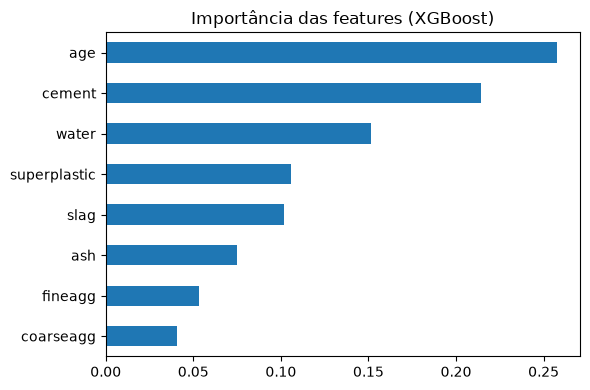

In [ ]:
importances = pd.Series(final_xgb.feature_importances_, index=df.drop(columns=[TARGET]).columns)
importances.sort_values().plot(kind="barh", figsize=(6, 4), title="Importância das features (XGBoost)")
plt.tight_layout()
plt.show()

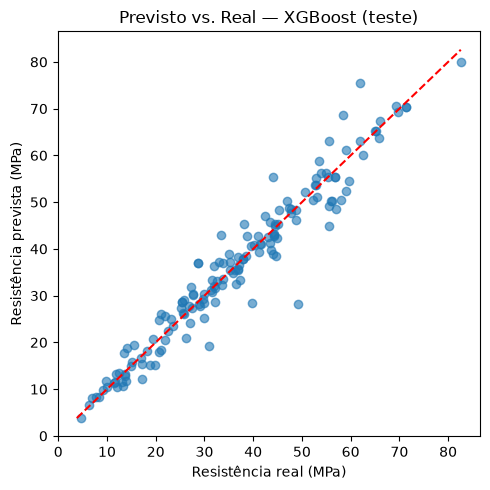

In [56]:
# Gráfico Previsto vs. Real, no mesmo estilo do que fizemos pra MLP
plt.figure(figsize=(5, 5))
plt.scatter(y_test, xgb_test_preds, alpha=0.6)
lims = [min(y_test.min(), xgb_test_preds.min()), max(y_test.max(), xgb_test_preds.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Resistência real (MPa)")
plt.ylabel("Resistência prevista (MPa)")
plt.title("Previsto vs. Real — XGBoost (teste)")
plt.tight_layout()
plt.show()

O XGBoost superou a MLP em todas as métricas (RMSE 4.12 vs. ~4.5–5.4 MPa; MAE 2.71 vs. ~3.6–3.85; R² 0.939 vs. ~0.89–0.91). Esse resultado é consistente com a literatura de aprendizado de máquina aplicada a dados tabulares de porte pequeno/médio, onde métodos de *gradient boosting* costumam superar redes neurais, o que não indica um problema com a MLP, mas uma característica esperada desse tipo de dado. Inclusive, o próprio professor destacou isto na análise da proposta de projeto.

A análise de importância de variáveis do XGBoost mostrou `age` e `cement` como as features mais relevantes, seguidas por `water` e `superplastic`, enquanto `fineagg` e `coarseagg` ficaram entre as menos importantes. Isso é coerente com o que já havia aparecido na matriz de correlação apresentada no início do notebook: `age` tinha correlação linear relativamente fraca com a resistência (0.33, contra 0.50 de `cement`), porém aparece à frente do cimento na importância calculada pelo XGBoost. A explicação é que a cura do concreto segue uma relação não linear com o tempo, ganho de resistência rápido nas primeiras idades, com desaceleração posterior, algo que a correlação de Pearson, por medir apenas relação linear, tende a subestimar. Modelos baseados em árvores capturam esse tipo de não linearidade sem exigir transformação manual da variável, o que explica a diferença de ranking entre a correlação simples e a importância do modelo.

Esse mesmo padrão, `age` como variável mais influente, à frente de `cement`, com `water` e `fly ash`/`coarse aggregate` em posição intermediária e `superplasticizer`/`fine aggregate` entre as menos relevantes, foi reportado em estudos que aplicaram SHAP sobre o mesmo dataset (1030 amostras, 8 variáveis) usando CatBoost e XGBoost (Kaggle/UCI Concrete Compressive Strength; ver [Al-Shamiri et al., 2024, Scientific Reports](https://www.nature.com/articles/s41598-024-66957-3); e [Naser & Alavi, 2023, Scientific Reports](https://www.nature.com/articles/s41598-023-47169-7)).

A menor relevância dos agregados graúdo e miúdo também tem respaldo na literatura da ciência dos materiais: em concreto convencional, o agregado atua principalmente como material de preenchimento ("filler"), e a resistência à compressão é controlada majoritariamente pela resistência da pasta de cimento e pela qualidade da ligação entre pasta e agregado, não pela resistência intrínseca do agregado em si ([ScienceDirect Topics, Aggregate Concrete](https://www.sciencedirect.com/topics/engineering/aggregate-concrete)). Isso explica por que essas variáveis contribuem menos para a previsão do modelo do que o teor de cimento, água e idade de cura.

Esse tópico será mais desenvolvido no documento final.

## 4. SHAP